In [32]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0        # (Dimension, Row, Column, Channel)        # 이전 신경망 모델에서는 숫자로 했지만 여기선 색도 포함시키게 할 거. 흑백 = 1

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

#### 합성곱(CNN) 층 만들기

In [33]:
model = keras.Sequential()
model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,  # 보통 정사각형으로 구성 (3,3)
        activation='relu',
        padding='same',  # 원본 이미지 크기과 같게  <=> valid
        input_shape=(28, 28, 1)
    )           # Conv2D(필터 갯수, 필터의 구성, 활성화 함수, padding, 형태)
)

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 풀링층

In [34]:
model.add(
    keras.layers.MaxPooling2D(2)    # 2*2 max pooling
)

#### 합성곱층

In [35]:
model.add(
    keras.layers.Conv2D(
        64,     # => 바뀜
        kernel_size=3,  # 보통 정사각형으로 구성 (3,3)
        activation='relu',
        padding='same',  # 원본 이미지 크기과 같게  <=> valid
    )
)
model.add(
    keras.layers.MaxPooling2D(2)    # 2*2 max pooling
)

#### Dense 층

In [36]:
# 입력층
model.add(
    keras.layers.Flatten()  # 평평하게 1차원으로 바꿔라
)

# 은닉층
model.add(
    keras.layers.Dense(100, activation='relu')
)

# Drop out 층
model.add(
    keras.layers.Dropout(0.5)   # 0.5 쳐내. train 잘 맞추는데 valid 못 맞출 때. 원래 출력 해보고 나서 조절하면 됨.
)

# 출력층
model.add(
    keras.layers.Dense(10, activation='softmax')
)

In [37]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Compile

In [38]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_cnn_model.keras' #,  save_best_only=True)
                                                )
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

#### Training

In [39]:
history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7943 - loss: 0.5750 - val_accuracy: 0.8753 - val_loss: 0.3368
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8668 - loss: 0.3751 - val_accuracy: 0.8895 - val_loss: 0.2960
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8865 - loss: 0.3180 - val_accuracy: 0.9004 - val_loss: 0.2725
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8988 - loss: 0.2862 - val_accuracy: 0.9066 - val_loss: 0.2508
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9070 - loss: 0.2607 - val_accuracy: 0.9101 - val_loss: 0.2415
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9129 - loss: 0.2399 - val_accuracy: 0.9162 - val_loss: 0.2314
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9179 - loss: 0.2252 - val_accuracy: 0.9163 - val_loss: 0.2297
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9220 - loss: 0.

#### 평가와 예측

In [40]:
model.evaluate(train_scaled, train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9516 - loss: 0.1306


[0.1305680274963379, 0.9516458511352539]

In [41]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9223 - loss: 0.2210


[0.22098417580127716, 0.9223333597183228]

#### 이미지로 확인하기

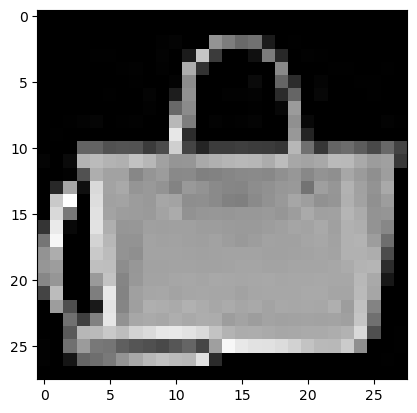

In [42]:
import matplotlib.pyplot as plt

plt.imshow(
    val_scaled[0].reshape(28, 28),
    cmap='gray'
)
plt.show()

In [43]:
pred = model.predict(
    val_scaled[:1]
)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


array([[2.1688117e-19, 4.7444387e-29, 4.2141237e-24, 1.4311119e-23,
        2.3540127e-22, 1.0825150e-18, 3.7987762e-22, 6.7376225e-23,
        1.0000000e+00, 2.7635181e-26]], dtype=float32)

In [44]:
# 글자로 변경하기
import numpy as np
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵글부츠']
len(classes)    # 가짓수 확인

10

In [45]:
classes[np.argmax(pred)]        # softmax 를 쓰면 argmax 를 써야 함.

'가방'

#### test data 로 확인하기

In [46]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9169 - loss: 0.2437


[0.2437315136194229, 0.9168999791145325]